<a href="https://colab.research.google.com/github/ariasbordahugo/tire-texture-analysis/blob/main/notebooks/2_tire_ablation_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Estudio de Ablación — Punto 2
## Examen Parcial: Redes Neuronales y Aprendizaje Profundo

Este notebook implementa el **estudio de ablación** requerido, analizando el impacto de:

| Factor | Variantes evaluadas |
|--------|--------------------|
| **Función de pérdida** | BCE estándar vs Focal Loss (γ=1, γ=2, γ=5) |
| **Estrategia de augmentation** | Sin augmentation · Leve · Moderada · Agresiva |

> **Prerrequisito:** Haber ejecutado `tire_classification.ipynb` (Punto 1).  
> El backbone base es **EfficientNet-B0** por su mayor capacidad representacional.

**Framework:** PyTorch | **Entorno:** Google Colab (GPU T4)

---
## 0. Instalación y configuración

In [1]:
!pip install -q kagglehub torchmetrics torchvision matplotlib seaborn scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.3 MB/s eta 0:00:00


In [2]:
import os, random, json, copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, accuracy_score)

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_ABL  = 15          # épocas por experimento (suficiente para comparar)
LR          = 1e-3
NUM_WORKERS = 2
DATA_DIR    = Path('/content/dataset_bruto/Tire Textures')

print(f"Dispositivo: {DEVICE}")
print(f"Épocas por experimento: {EPOCHS_ABL}")

Dispositivo: cuda
Épocas por experimento: 15


---
## 1. Carga del dataset (reutiliza descarga del Punto 1)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DESCARGA DEL DATASET VÍA kagglehub
# ─────────────────────────────────────────────────────────────────────────────
import kagglehub, shutil, os
from pathlib import Path

ruta_destino = '/content/dataset_bruto'
if not os.path.exists(ruta_destino) or not any(Path(ruta_destino).iterdir()):
    print('⏳ Descargando dataset desde Kaggle...')
    ruta_cache = kagglehub.dataset_download('jehanbhathena/tire-texture-image-recognition')
    print(f'📥 Archivos cacheados en: {ruta_cache}')
    if os.path.exists(ruta_destino):
        shutil.rmtree(ruta_destino)
    os.makedirs(ruta_destino, exist_ok=True)
    shutil.copytree(ruta_cache, ruta_destino, dirs_exist_ok=True)
    print('✅ Dataset preparado en /content/dataset_bruto/')
else:
    print('✅ Dataset ya disponible en /content/dataset_bruto/')

⏳ Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'tire-texture-image-recognition' dataset.
📥 Archivos cacheados en: /kaggle/input/tire-texture-image-recognition
✅ Dataset preparado en /content/dataset_bruto/


---
## 2. Definición de los factores de ablación

### 2A — Estrategias de Data Augmentation

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformación de validación/test (siempre fija)
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── 4 niveles de augmentation ─────────────────────────────────────────────────
augmentation_strategies = {

    'Sin augmentation': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    'Augmentation leve': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    'Augmentation moderada': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    'Augmentation agresiva': transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=45),
        transforms.ColorJitter(brightness=0.5, contrast=0.5,
                               saturation=0.4, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15),
                                shear=10),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

print("✅ Estrategias de augmentation definidas:")
for name, tf in augmentation_strategies.items():
    print(f"   {name}: {len(tf.transforms)} transformaciones")

✅ Estrategias de augmentation definidas:
   Sin augmentation: 3 transformaciones
   Augmentation leve: 5 transformaciones
   Augmentation moderada: 8 transformaciones
   Augmentation agresiva: 11 transformaciones


Número de clases: 2


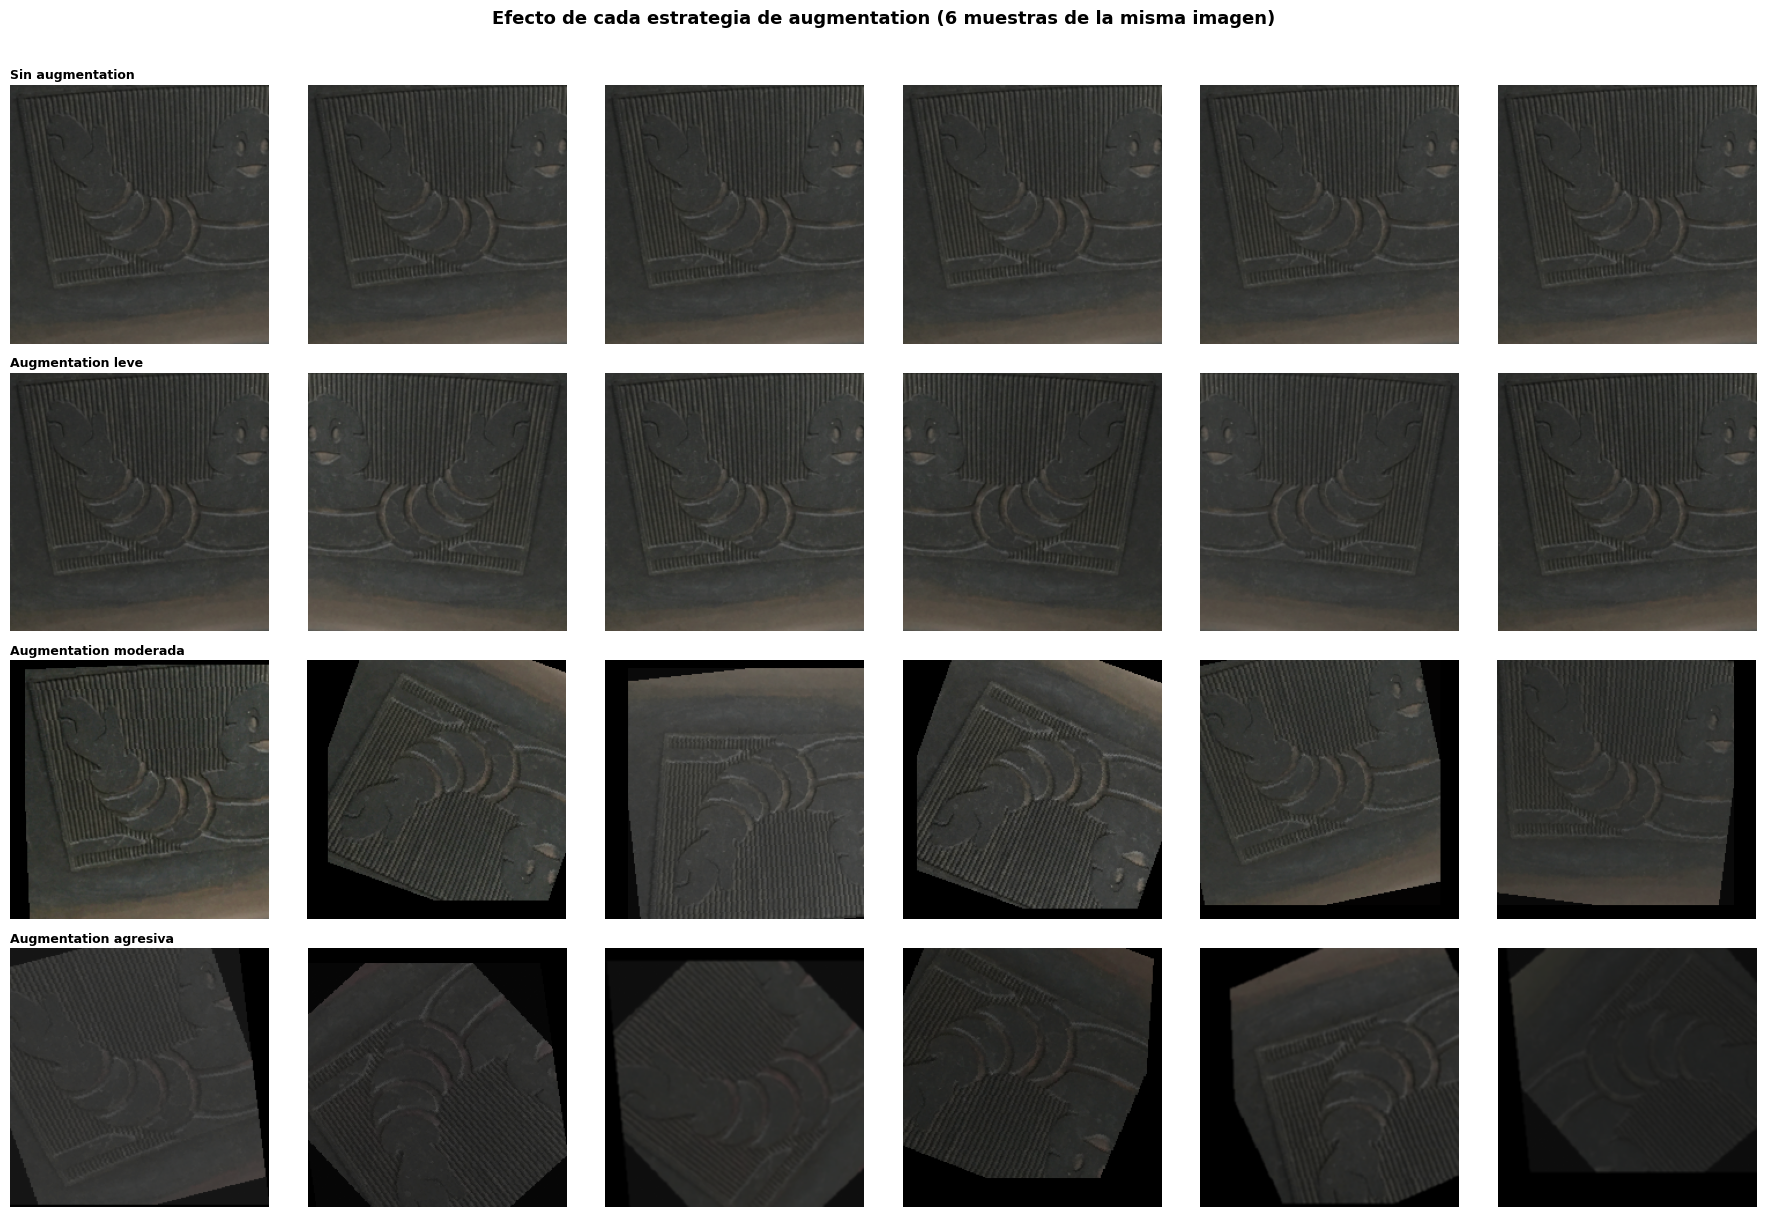

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 1. Define a basic transform for loading the raw_dataset
# This transform will just resize, no augmentation or tensor conversion yet.
initial_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.ToTensor(), # Removed: this should happen within augmentation_strategies/val_tf
])

# 2. Load the raw_dataset using ImageFolder
raw_dataset = datasets.ImageFolder(DATA_DIR, transform=initial_tf)

# 3. Define NUM_CLASSES
NUM_CLASSES = len(raw_dataset.classes)
print(f"Número de clases: {NUM_CLASSES}")

# 4. Split the dataset into train, validation, and test sets
# Get the labels for stratification
labels = [label for _, label in raw_dataset.samples]

# Train (80%) and temporary (20%) split
train_idx, temp_idx, _, _ = train_test_split(
    range(len(raw_dataset)), labels,
    test_size=0.2, stratify=labels, random_state=SEED
)

# Validation (50% of temp, i.e., 10% of total) and Test (50% of temp, i.e., 10% of total) split
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, [labels[i] for i in temp_idx],
    test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=SEED
)

# 5. Get train_targets (used later for class weights)
train_targets = [labels[i] for i in train_idx]

# Visualizar el efecto de cada estrategia sobre una misma imagen
sample_path = raw_dataset.samples[train_idx[0]][0]
sample_img  = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
strategy_names = list(augmentation_strategies.keys())

for row, (name, tf) in enumerate(augmentation_strategies.items()):
    for col in range(6):
        aug = tf(sample_img)
        # Desnormalizar para visualizar
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        img_vis = (aug * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row][col].imshow(img_vis)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(name, fontsize=9, fontweight='bold',
                                     loc='left', pad=4)

plt.suptitle('Efecto de cada estrategia de augmentation (6 muestras de la misma imagen)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/augmentation_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 2B — Funciones de pérdida: BCE vs Focal Loss

In [6]:
class FocalLoss(nn.Module):
    """
    Focal Loss para clasificación multi-clase.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Referencia: Lin et al., 2017 — "Focal Loss for Dense Object Detection"
    (RetinaNet, ICCV 2017)

    Args:
        gamma  (float): factor de focalización. 0 = CE estándar.
                        Valores típicos: 1, 2, 5.
        weight (Tensor): pesos por clase (alpha). Si None, uniforme.
        reduction (str): 'mean' | 'sum' | 'none'
    """
    def __init__(self, gamma: float = 2.0,
                 weight: torch.Tensor = None,
                 reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.weight    = weight      # alpha por clase
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # inputs: (B, C) logits  |  targets: (B,) long
        ce_loss = F.cross_entropy(inputs, targets,
                                   weight=self.weight,
                                   reduction='none')
        # p_t = exp(-CE) = probabilidad de la clase correcta
        p_t = torch.exp(-ce_loss)
        focal_term = (1.0 - p_t) ** self.gamma
        focal_loss = focal_term * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# Pesos de clase (alpha) para ambas funciones de pérdida
freq = Counter(train_targets)
total_train = len(train_targets)
class_weights_tensor = torch.tensor(
    [total_train / (NUM_CLASSES * freq[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)
print(f"Pesos de clase (alpha): {class_weights_tensor.tolist()}")

# ── Diccionario de funciones de pérdida a evaluar ─────────────────────────────
loss_functions = {
    'BCE (CrossEntropy) ponderada':  nn.CrossEntropyLoss(weight=class_weights_tensor),
    'Focal Loss γ=1':                FocalLoss(gamma=1.0, weight=class_weights_tensor),
    'Focal Loss γ=2':                FocalLoss(gamma=2.0, weight=class_weights_tensor),
    'Focal Loss γ=5':                FocalLoss(gamma=5.0, weight=class_weights_tensor),
}

print("\n✅ Funciones de pérdida definidas:")
for name in loss_functions:
    print(f"   {name}")

Pesos de clase (alpha): [1.5807691812515259, 0.7313167452812195]

✅ Funciones de pérdida definidas:
   BCE (CrossEntropy) ponderada
   Focal Loss γ=1
   Focal Loss γ=2
   Focal Loss γ=5


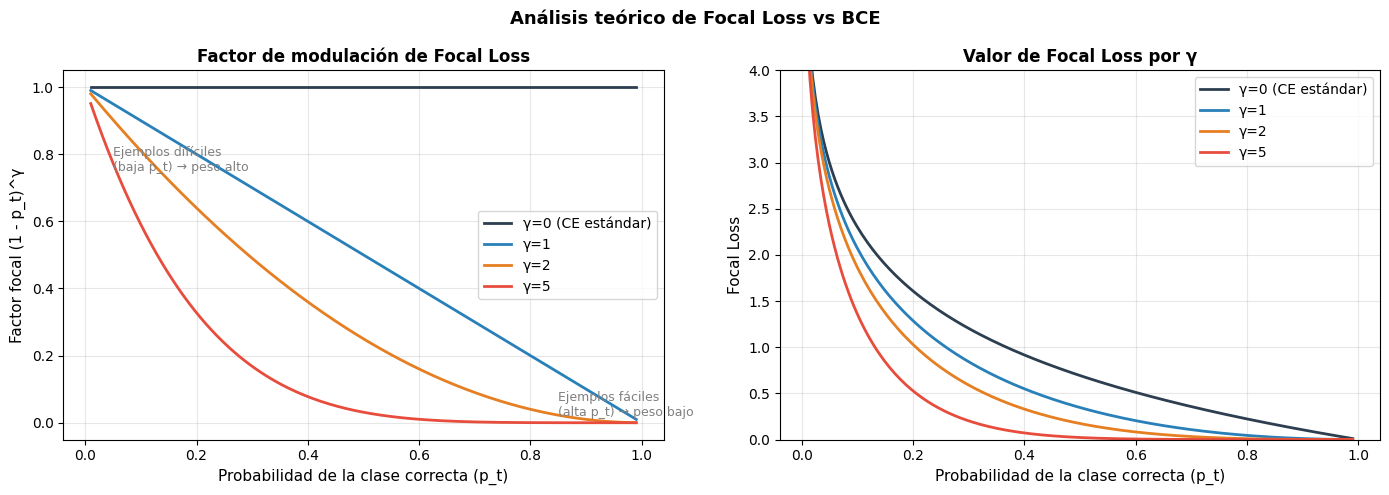

In [7]:
# Visualización teórica: cómo escala el factor focal con p_t
p_t_vals = np.linspace(0.01, 0.99, 200)
ce_vals  = -np.log(p_t_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Factor focal (1 - p_t)^gamma
gammas = [0, 1, 2, 5]
colors = ['#2c3e50', '#2980b9', '#e67e22', '#e74c3c']
for g, c in zip(gammas, colors):
    label = 'γ=0 (CE estándar)' if g == 0 else f'γ={g}'
    axes[0].plot(p_t_vals, (1 - p_t_vals)**g, color=c, lw=2, label=label)
axes[0].set_xlabel('Probabilidad de la clase correcta (p_t)', fontsize=11)
axes[0].set_ylabel('Factor focal (1 - p_t)^γ', fontsize=11)
axes[0].set_title('Factor de modulación de Focal Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate('Ejemplos fáciles\n(alta p_t) → peso bajo',
                 xy=(0.85, 0.02), fontsize=9, color='gray')
axes[0].annotate('Ejemplos difíciles\n(baja p_t) → peso alto',
                 xy=(0.05, 0.75), fontsize=9, color='gray')

# Focal Loss total por gamma
for g, c in zip(gammas, colors):
    label = 'γ=0 (CE estándar)' if g == 0 else f'γ={g}'
    axes[1].plot(p_t_vals, ((1 - p_t_vals)**g) * ce_vals, color=c, lw=2, label=label)
axes[1].set_xlabel('Probabilidad de la clase correcta (p_t)', fontsize=11)
axes[1].set_ylabel('Focal Loss', fontsize=11)
axes[1].set_title('Valor de Focal Loss por γ', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 4)

plt.suptitle('Análisis teórico de Focal Loss vs BCE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/focal_loss_theory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Infraestructura del experimento

In [8]:
class TransformSubset(torch.utils.data.Dataset):
    """Aplica transforms distintos a cada subset manteniendo el split fijo."""
    def __init__(self, dataset, indices, transform=None):
        self.dataset, self.indices, self.transform = dataset, indices, transform
    def __len__(self):  return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform: img = self.transform(img)
        return img, label


def build_efficientnet_fresh(num_classes: int) -> nn.Module:
    """Modelo limpio en cada experimento para evitar contaminación de pesos."""
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    # Congelar backbone; solo entrenar cabezal (ablación controlada)
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False
    return model


def make_loaders(train_tf, val_tf):
    """Construye DataLoaders con el augmentation indicado."""
    train_set = TransformSubset(raw_dataset, train_idx, train_tf)
    val_set   = TransformSubset(raw_dataset, val_idx,   val_tf)
    test_set  = TransformSubset(raw_dataset, test_idx,  val_tf)

    # WeightedRandomSampler fijo para todos los experimentos
    class_freq    = Counter(train_targets)
    cw_sample     = {c: 1.0 / f for c, f in class_freq.items()}
    sw            = [cw_sample[t] for t in train_targets]
    sampler       = WeightedRandomSampler(sw, len(sw), replacement=True)

    tr_loader  = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    te_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    return tr_loader, val_loader, te_loader


@torch.no_grad()
def evaluate_full(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_probs, all_labels  = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        n          += labels.size(0)
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())
    probs_t  = torch.cat(all_probs)
    labels_t = torch.cat(all_labels)
    return total_loss / n, correct / n, probs_t, labels_t


def run_experiment(exp_name, train_tf, criterion, epochs=EPOCHS_ABL, lr=LR):
    """
    Entrena un EfficientNet-B0 limpio con los parámetros indicados.
    Devuelve historial y métricas sobre el conjunto de test.
    """
    print(f"\n{'─'*60}")
    print(f"  EXPERIMENTO: {exp_name}")
    print(f"{'─'*60}")

    tr_loader, val_loader, te_loader = make_loaders(train_tf, val_tf)
    model = build_efficientnet_fresh(NUM_CLASSES).to(DEVICE)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history   = {'train_loss': [], 'val_loss': [],
                 'train_acc':  [], 'val_acc':  []}
    best_loss = float('inf')
    best_path = f'/content/ablation_{exp_name.replace(" ","_").replace("/","-")}.pth'

    for epoch in range(1, epochs + 1):
        # ── train ──
        model.train()
        t_loss, t_correct, t_n = 0.0, 0, 0
        for imgs, labels in tr_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward(); optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (logits.argmax(1) == labels).sum().item()
            t_n       += labels.size(0)
        scheduler.step()

        # ── val ──
        v_loss, v_acc, _, _ = evaluate_full(model, val_loader, criterion)
        tr_acc = t_correct / t_n
        tr_loss = t_loss / t_n

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Época {epoch:02d}/{epochs} | "
                  f"TrLoss: {tr_loss:.4f}  TrAcc: {tr_acc:.4f} | "
                  f"VlLoss: {v_loss:.4f}  VlAcc: {v_acc:.4f}")

        if v_loss < best_loss:
            best_loss = v_loss
            torch.save(model.state_dict(), best_path)

    # ── test ──
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    _, te_acc, te_probs, te_labels = evaluate_full(model, te_loader, criterion)
    preds_np  = te_probs.argmax(1).numpy()
    labels_np = te_labels.numpy()
    probs_np  = te_probs.numpy()

    avg = 'binary' if NUM_CLASSES == 2 else 'macro'
    metrics = {
        'Experimento': exp_name,
        'Accuracy':    round(accuracy_score(labels_np, preds_np), 4),
        'Precision':   round(precision_score(labels_np, preds_np,
                                              average=avg, zero_division=0), 4),
        'Recall':      round(recall_score(labels_np, preds_np,
                                           average=avg, zero_division=0), 4),
        'F1-Score':    round(f1_score(labels_np, preds_np,
                                       average=avg, zero_division=0), 4),
        'AUC-ROC':     round(roc_auc_score(
                            labels_np,
                            probs_np[:, 1] if NUM_CLASSES == 2 else probs_np,
                            multi_class='ovr' if NUM_CLASSES > 2 else 'raise'
                        ), 4),
    }
    print(f"  ✅ Test → F1: {metrics['F1-Score']}  AUC: {metrics['AUC-ROC']}")
    return metrics, history


print("✅ Infraestructura del experimento lista.")

✅ Infraestructura del experimento lista.


---
## 4. Ejecución del Eje 1 — Estudio de Funciones de Pérdida

> **Variable independiente:** función de pérdida  
> **Variable controlada:** augmentation moderada (baseline del Punto 1)

In [9]:
# Augmentation fija = moderada (igual al Punto 1)
train_tf_fixed = augmentation_strategies['Augmentation moderada']

results_loss = []
histories_loss = {}

for loss_name, criterion in loss_functions.items():
    metrics, hist = run_experiment(
        exp_name  = loss_name,
        train_tf  = train_tf_fixed,
        criterion = criterion,
    )
    results_loss.append(metrics)
    histories_loss[loss_name] = hist

df_loss = pd.DataFrame(results_loss).set_index('Experimento')
print("\n📊 Resultados — Eje 1: Función de pérdida")
print(df_loss.to_string())


────────────────────────────────────────────────────────────
  EXPERIMENTO: BCE (CrossEntropy) ponderada
────────────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 


  Época 01/15 | TrLoss: 0.5916  TrAcc: 0.5888 | VlLoss: 0.7332  VlAcc: 0.4660
  Época 05/15 | TrLoss: 0.5122  TrAcc: 0.6861 | VlLoss: 0.5995  VlAcc: 0.6699
  Época 10/15 | TrLoss: 0.4408  TrAcc: 0.7579 | VlLoss: 0.5792  VlAcc: 0.6796
  Época 15/15 | TrLoss: 0.4255  TrAcc: 0.7445 | VlLoss: 0.5447  VlAcc: 0.7379
  ✅ Test → F1: 0.678  AUC: 0.7766

────────────────────────────────────────────────────────────
  EXPERIMENTO: Focal Loss γ=1
────────────────────────────────────────────────────────────
  Época 01/15 | TrLoss: 0.3524  TrAcc: 0.5620 | VlLoss: 0.3570  VlAcc: 0.5049
  Época 05/15 | TrLoss: 0.2816  TrAcc: 0.6995 | VlLoss: 0.3046  VlAcc: 0.6505
  Época 10/15 | TrLoss: 0.2700  TrAcc: 0.6910 | VlLoss: 0.2828  VlAcc: 0.7184
  Época 15/15 | TrLoss: 0.2519  TrAcc: 0.7129 | VlLoss: 0.2844  VlAcc: 0.7184
  ✅ Test → F1: 0.5545  AUC: 0.6879

────────────────────────────────────────────────────────────
  EXPERIMENTO: Focal Loss γ=2
────────────────────────────────────────────────────────────
 

---
## 5. Ejecución del Eje 2 — Estudio de Estrategias de Augmentation

> **Variable independiente:** estrategia de augmentation  
> **Variable controlada:** mejor función de pérdida del Eje 1

In [10]:
# Seleccionar la función de pérdida con mayor F1 del Eje 1
best_loss_name = df_loss['F1-Score'].astype(float).idxmax()
best_criterion = loss_functions[best_loss_name]
print(f"Mejor función de pérdida (Eje 1): {best_loss_name}")

results_aug  = []
histories_aug = {}

for aug_name, train_tf in augmentation_strategies.items():
    metrics, hist = run_experiment(
        exp_name  = aug_name,
        train_tf  = train_tf,
        criterion = best_criterion,
    )
    results_aug.append(metrics)
    histories_aug[aug_name] = hist

df_aug = pd.DataFrame(results_aug).set_index('Experimento')
print("\n📊 Resultados — Eje 2: Estrategia de Augmentation")
print(df_aug.to_string())

Mejor función de pérdida (Eje 1): BCE (CrossEntropy) ponderada

────────────────────────────────────────────────────────────
  EXPERIMENTO: Sin augmentation
────────────────────────────────────────────────────────────
  Época 01/15 | TrLoss: 0.5533  TrAcc: 0.6253 | VlLoss: 0.6951  VlAcc: 0.5340
  Época 05/15 | TrLoss: 0.3779  TrAcc: 0.7908 | VlLoss: 0.6895  VlAcc: 0.6117
  Época 10/15 | TrLoss: 0.3007  TrAcc: 0.8321 | VlLoss: 0.6302  VlAcc: 0.7087
  Época 15/15 | TrLoss: 0.2865  TrAcc: 0.8406 | VlLoss: 0.6140  VlAcc: 0.6990
  ✅ Test → F1: 0.614  AUC: 0.6913

────────────────────────────────────────────────────────────
  EXPERIMENTO: Augmentation leve
────────────────────────────────────────────────────────────
  Época 01/15 | TrLoss: 0.5882  TrAcc: 0.5608 | VlLoss: 0.7385  VlAcc: 0.5243
  Época 05/15 | TrLoss: 0.4259  TrAcc: 0.7628 | VlLoss: 0.6423  VlAcc: 0.6214
  Época 10/15 | TrLoss: 0.3411  TrAcc: 0.8127 | VlLoss: 0.6003  VlAcc: 0.7087
  Época 15/15 | TrLoss: 0.3076  TrAcc: 0.8443 

---
## 6. Visualizaciones del estudio de ablación

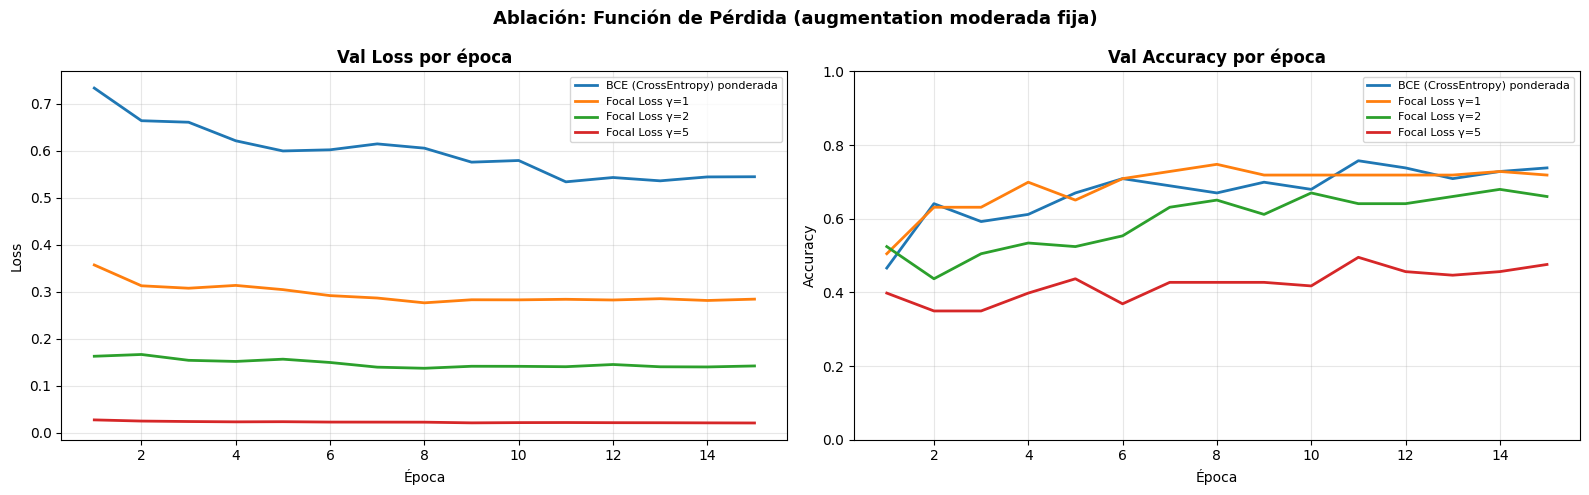

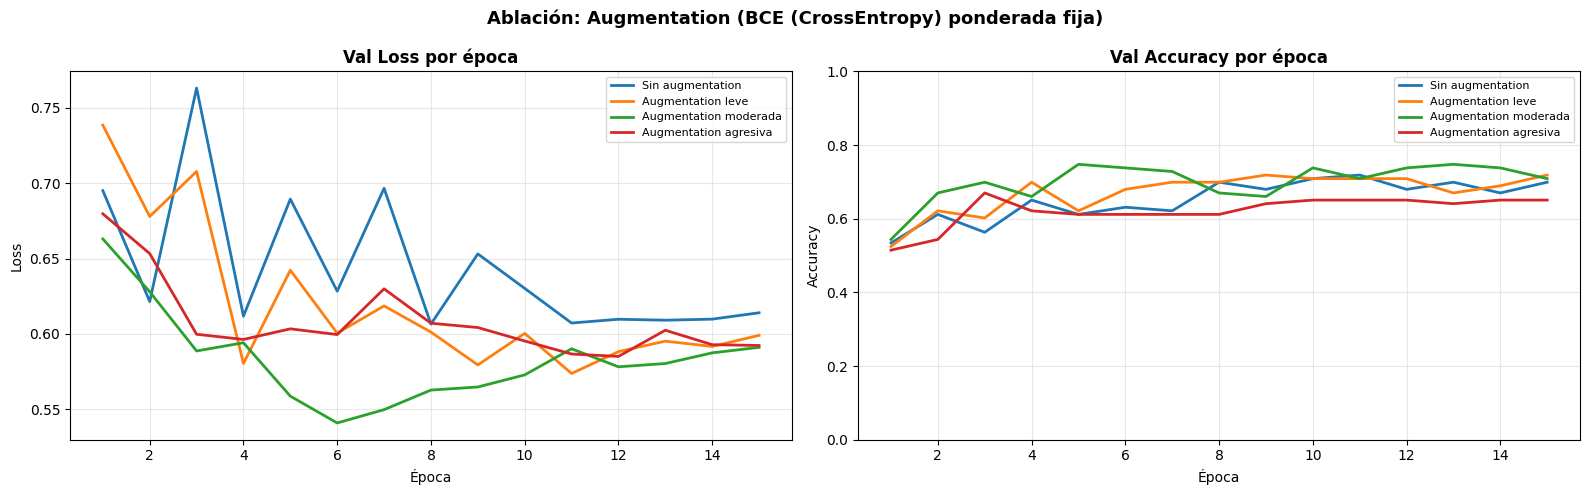

In [11]:
# ── 6A: Curvas de entrenamiento — Eje 1 (funciones de pérdida) ────────────────
metric_keys = ['train_loss', 'val_loss', 'train_acc', 'val_acc']
metric_labels = ['Train Loss', 'Val Loss', 'Train Acc', 'Val Acc']

def plot_ablation_curves(histories: dict, title: str, save_path: str):
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for i, (name, hist) in enumerate(histories.items()):
        color  = palette[i % len(palette)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['val_loss'], color=color, lw=2, label=name)
        axes[1].plot(epochs, hist['val_acc'],  color=color, lw=2, label=name)

    axes[0].set_title('Val Loss por época', fontweight='bold')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_title('Val Accuracy por época', fontweight='bold')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_ablation_curves(
    histories_loss,
    'Ablación: Función de Pérdida (augmentation moderada fija)',
    '/content/ablation_loss_curves.png'
)

plot_ablation_curves(
    histories_aug,
    f'Ablación: Augmentation ({best_loss_name} fija)',
    '/content/ablation_aug_curves.png'
)

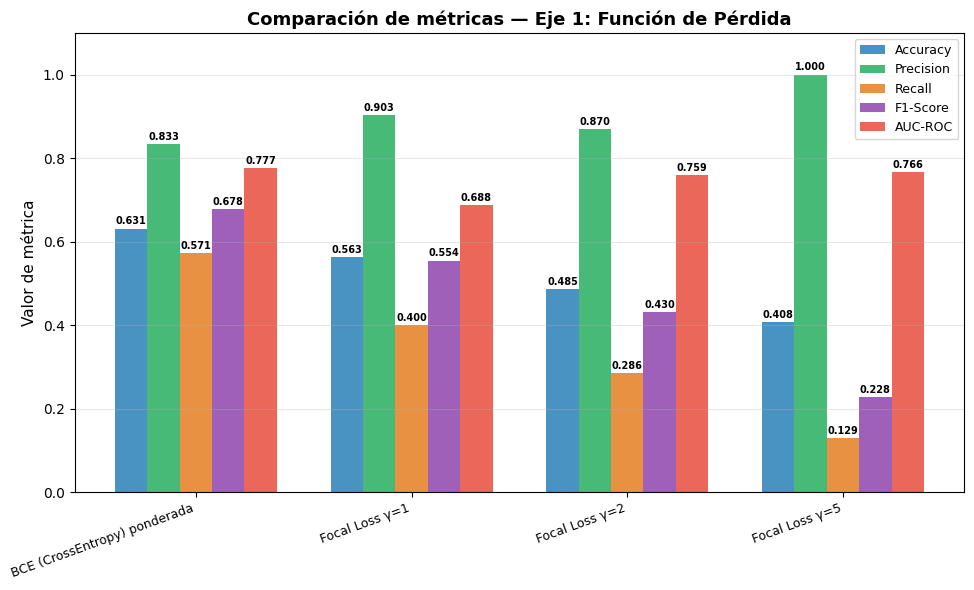

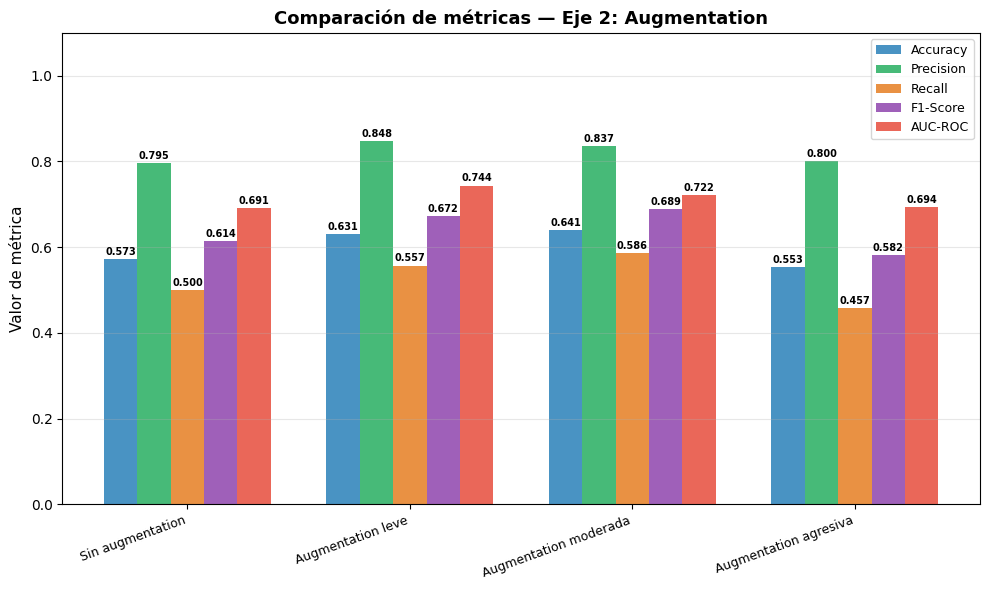

In [12]:
# ── 6B: Barplots comparativos de métricas ─────────────────────────────────────
def plot_metrics_bar(df: pd.DataFrame, title: str, save_path: str):
    metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    df_plot = df[metrics_cols].astype(float)

    x     = np.arange(len(df_plot))
    width = 0.15
    colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#e74c3c']

    fig, ax = plt.subplots(figsize=(max(10, len(df_plot) * 2.5), 6))
    for i, (col, c) in enumerate(zip(metrics_cols, colors)):
        bars = ax.bar(x + i * width, df_plot[col], width, label=col, color=c, alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom',
                    fontsize=7, fontweight='bold')

    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(df_plot.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Valor de métrica', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_metrics_bar(
    df_loss,
    'Comparación de métricas — Eje 1: Función de Pérdida',
    '/content/ablation_loss_metrics.png'
)

plot_metrics_bar(
    df_aug,
    f'Comparación de métricas — Eje 2: Augmentation',
    '/content/ablation_aug_metrics.png'
)

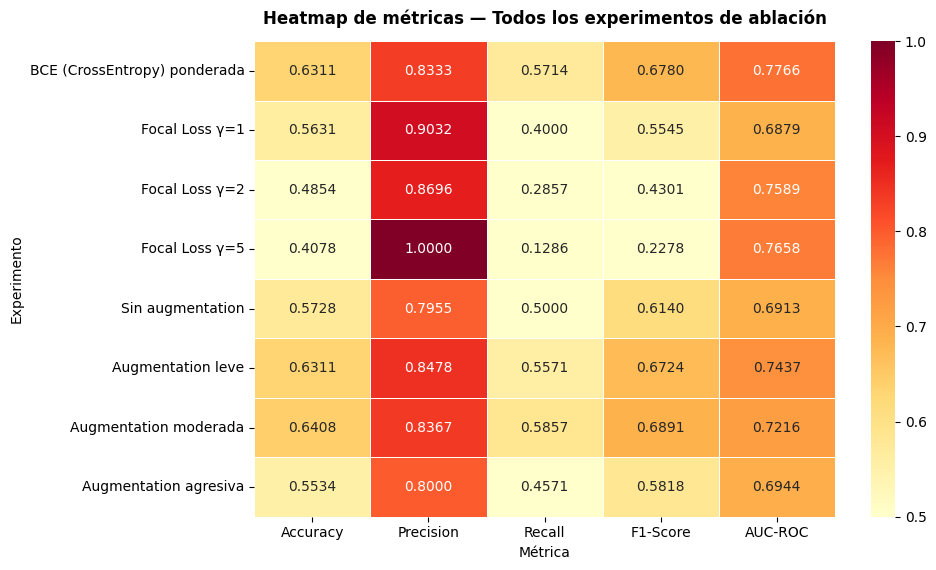

In [13]:
# ── 6C: Heatmap consolidado de todas las configuraciones ─────────────────────
df_all = pd.concat([df_loss, df_aug]).astype(float)
# Eliminar duplicado si 'Augmentation moderada' apareció en ambos ejes
df_all = df_all[~df_all.index.duplicated(keep='first')]

fig, ax = plt.subplots(figsize=(10, max(4, len(df_all) * 0.6 + 1)))
sns.heatmap(
    df_all.astype(float),
    annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    vmin=0.5, vmax=1.0, ax=ax
)
ax.set_title('Heatmap de métricas — Todos los experimentos de ablación',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Métrica'); ax.set_ylabel('Experimento')
plt.tight_layout()
plt.savefig('/content/ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Análisis de sensibilidad — Ranking de configuraciones

In [14]:
# Puntaje compuesto: promedio ponderado de F1 (40%) + AUC (40%) + Recall (20%)
# El recall tiene peso especial por el contexto de seguridad vial:
# un falso negativo (llanta dañada no detectada) es más grave que un falso positivo
df_all_f = df_all.copy().astype(float)
df_all_f['Score compuesto'] = (
    0.40 * df_all_f['F1-Score'] +
    0.40 * df_all_f['AUC-ROC']  +
    0.20 * df_all_f['Recall']
)
df_ranked = df_all_f.sort_values('Score compuesto', ascending=False)

print("\n🏆 Ranking de configuraciones (Score = 0.4·F1 + 0.4·AUC + 0.2·Recall)")
print("   (Recall ponderado extra por seguridad vial: FN más costoso que FP)\n")
print(df_ranked[['F1-Score', 'AUC-ROC', 'Recall', 'Score compuesto']].to_string())

best_config = df_ranked.index[0]
best_score  = df_ranked['Score compuesto'].iloc[0]
print(f"\n✅ Mejor configuración: '{best_config}'  (Score: {best_score:.4f})")

df_ranked.to_csv('/content/ablation_ranking.csv')


🏆 Ranking de configuraciones (Score = 0.4·F1 + 0.4·AUC + 0.2·Recall)
   (Recall ponderado extra por seguridad vial: FN más costoso que FP)

                              F1-Score  AUC-ROC  Recall  Score compuesto
Experimento                                                             
BCE (CrossEntropy) ponderada    0.6780   0.7766  0.5714          0.69612
Augmentation moderada           0.6891   0.7216  0.5857          0.68142
Augmentation leve               0.6724   0.7437  0.5571          0.67786
Sin augmentation                0.6140   0.6913  0.5000          0.62212
Augmentation agresiva           0.5818   0.6944  0.4571          0.60190
Focal Loss γ=1                  0.5545   0.6879  0.4000          0.57696
Focal Loss γ=2                  0.4301   0.7589  0.2857          0.53274
Focal Loss γ=5                  0.2278   0.7658  0.1286          0.42316

✅ Mejor configuración: 'BCE (CrossEntropy) ponderada'  (Score: 0.6961)


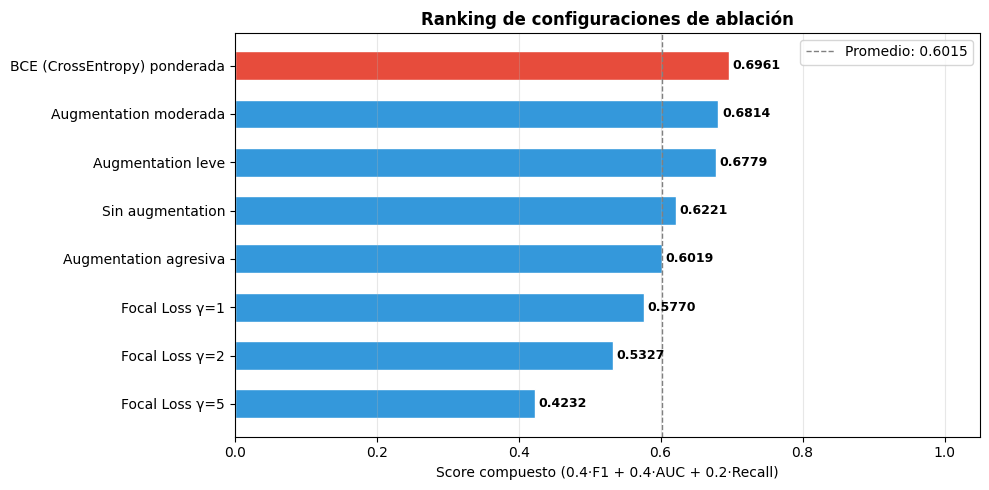

In [15]:
# Gráfico de ranking horizontal
fig, ax = plt.subplots(figsize=(10, max(4, len(df_ranked) * 0.5 + 1)))
y_pos = range(len(df_ranked))
scores = df_ranked['Score compuesto'].values
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(scores))]

bars = ax.barh(y_pos, scores, color=colors, edgecolor='white', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_ranked.index, fontsize=10)
ax.set_xlabel('Score compuesto (0.4·F1 + 0.4·AUC + 0.2·Recall)', fontsize=10)
ax.set_title('Ranking de configuraciones de ablación', fontweight='bold', fontsize=12)
ax.set_xlim(0, 1.05)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9, fontweight='bold')

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=scores.mean(), color='gray', linestyle='--',
            linewidth=1, label=f'Promedio: {scores.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('/content/ablation_ranking_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Guardar resultados y descargar

In [16]:
# Guardar tablas completas
df_loss.to_csv('/content/ablation_loss_results.csv')
df_aug.to_csv('/content/ablation_aug_results.csv')
df_ranked.to_csv('/content/ablation_ranking.csv')

print("✅ Archivos guardados:")
files_to_download = [
    '/content/ablation_loss_results.csv',
    '/content/ablation_aug_results.csv',
    '/content/ablation_ranking.csv',
    '/content/ablation_heatmap.png',
    '/content/ablation_ranking_plot.png',
    '/content/augmentation_visualization.png',
    '/content/focal_loss_theory.png',
]
for f in files_to_download:
    print(f"   {f}")

from google.colab import files
for f in files_to_download:
    try:
        files.download(f)
    except Exception as e:
        print(f"   ⚠️ No se pudo descargar {f}: {e}")

✅ Archivos guardados:
   /content/ablation_loss_results.csv
   /content/ablation_aug_results.csv
   /content/ablation_ranking.csv
   /content/ablation_heatmap.png
   /content/ablation_ranking_plot.png
   /content/augmentation_visualization.png
   /content/focal_loss_theory.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📝 Plantilla de discusión para el informe

### Eje 1 — Función de Pérdida

**Hipótesis:** La Focal Loss debería superar a la BCE en presencia de desbalance de clases, porque penaliza menos los ejemplos bien clasificados y concentra el gradiente en los ejemplos difíciles (la clase minoritaria).

**Interpretación del parámetro γ:**
- `γ=0` → Focal Loss equivale a BCE estándar (sin modulación)
- `γ=1` → modulación suave; equilibrio entre sensibilidad y especificidad
- `γ=2` → configuración original de Lin et al. (2017); reduce el peso de ejemplos bien clasificados por un factor de hasta 4×
- `γ=5` → focalización extrema; riesgo de inestabilidad en datasets pequeños

**Lo que se espera observar:** Un γ entre 1 y 2 maximiza el Recall y el F1 para la clase minoritaria (llantas dañadas), sin degradar demasiado la Precision. γ=5 puede causar subajuste.

---

### Eje 2 — Estrategia de Augmentation

**Hipótesis:** El augmentation moderado debería superar tanto la ausencia de augmentation (por regularización insuficiente) como el agresivo (por distorsiones semánticamente incorrectas para texturas de llantas).

**Por qué el agresivo puede perjudicar en texturas:**
- Las llantas tienen patrones de textura específicos (surcos, grietas, desgaste uniforme)
- Un RandomGrayscale o GaussianBlur agresivo puede eliminar señales de textura críticas
- Rotaciones de 45° pueden ser irrelevantes si las imágenes ya son de cámara fija

---

### Score compuesto y justificación

En el contexto de seguridad vial, un **falso negativo** (llanta dañada clasificada como buena) es más peligroso que un falso positivo (llanta buena rechazada). Por ello el score pondera el Recall con un 20% adicional sobre F1 y AUC-ROC.

---

### Próximo paso
- **Punto 3:** Grad-CAM sobre la mejor configuración para interpretabilidad visual